# Titanic Data Visualization — matplotlib & seaborn

A practical tour of plotting the classic **Titanic** dataset with the two core Python viz libraries:

- **matplotlib** — the foundational, low-level library. Full control over figures and axes.
- **seaborn** — built on top of matplotlib. High-level statistical plots with sensible defaults and less code.

The two work together: seaborn returns matplotlib axes, so you can mix them freely.

**Sections**
1. Setup & load data
2. Light preparation
3. matplotlib fundamentals
4. seaborn: distributions of single variables
5. seaborn: who survived? (categorical relationships)
6. Numeric relationships & correlation heatmap
7. Multivariate / faceted views
8. A combined dashboard figure

**Data:** Titanic (891 passengers, 15 columns), loaded live from the seaborn-data GitHub mirror.

## 1. Setup & load data

`%matplotlib inline` makes plots render in the notebook. We set a seaborn theme once — it restyles matplotlib globally, so even pure-matplotlib plots look better.

In [ ]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")   # global styling
plt.rcParams["figure.figsize"] = (8, 5)              # default figure size

print("seaborn", sns.__version__, "| matplotlib", plt.matplotlib.__version__)

seaborn 0.13.2 | matplotlib 3.10.0


In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv")
print("shape:", df.shape)
df.head()

shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Light preparation

A couple of tweaks make the charts read better: a human-friendly label for survival, and a binned age group.

In [ ]:
df["survived_label"] = df["survived"].map({0: "Died", 1: "Survived"})
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"],
)
df[["age", "age_group", "survived", "survived_label"]].head()

,age,age_group,survived,survived_label
0,22.0,Young Adult,0,Died
1,38.0,Adult,1,Survived
2,26.0,Young Adult,1,Survived
3,35.0,Young Adult,1,Survived
4,35.0,Young Adult,0,Died


## 3. matplotlib fundamentals

The core matplotlib pattern is **figure + axes**: create them with `plt.subplots()`, then draw onto the `ax` object. This is the recommended ("object-oriented") style.

### A histogram — distribution of passenger age

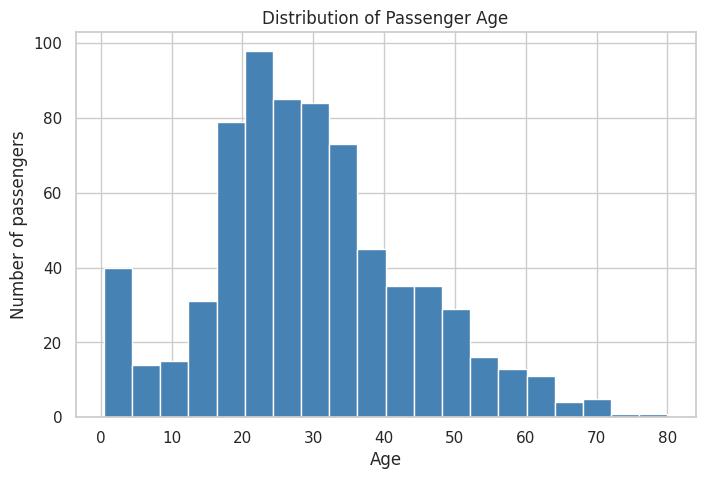

In [ ]:
fig, ax = plt.subplots()
ax.hist(df["age"].dropna(), bins=20, color="steelblue", edgecolor="white")
ax.set_title("Distribution of Passenger Age")
ax.set_xlabel("Age")
ax.set_ylabel("Number of passengers")
plt.show()

In [ ]:
fig, ax = plt.subplots()
ax.pie(df["sex"].dropna())
ax.set_title("Distribution by gender")
plt.show()

In [ ]:
sns.countplot(data=df, x="embarked", hue="embarked", legend=False)
plt.title("Passengers per 	embarked")
plt.show()

### A bar chart — passenger count by class
Counting in pandas, then drawing the bars manually with matplotlib.

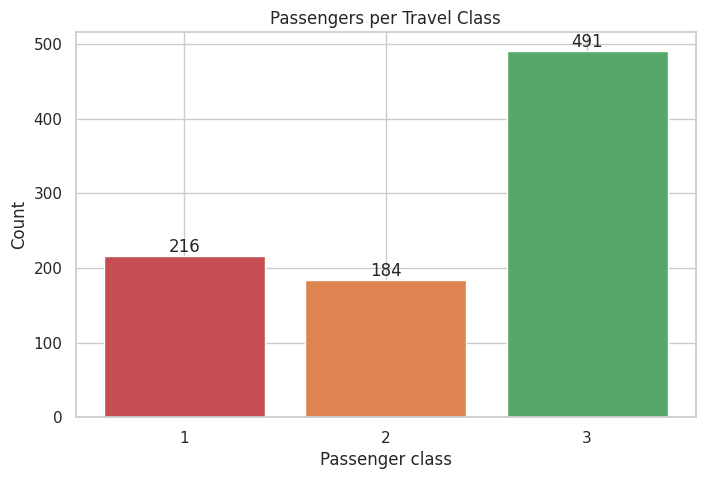

In [ ]:
class_counts = df["pclass"].value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(class_counts.index.astype(str), class_counts.values,
       color=["#c44e52", "#dd8452", "#55a868"])
ax.set_title("Passengers per Travel Class")
ax.set_xlabel("Passenger class")
ax.set_ylabel("Count")
for i, v in zip(class_counts.index.astype(str), class_counts.values):
    ax.text(i, v + 5, str(v), ha="center")   # annotate each bar
plt.show()

## 4. seaborn: distributions of single variables

Now the same kind of ideas, but seaborn does more with less.

### Count of a categorical variable

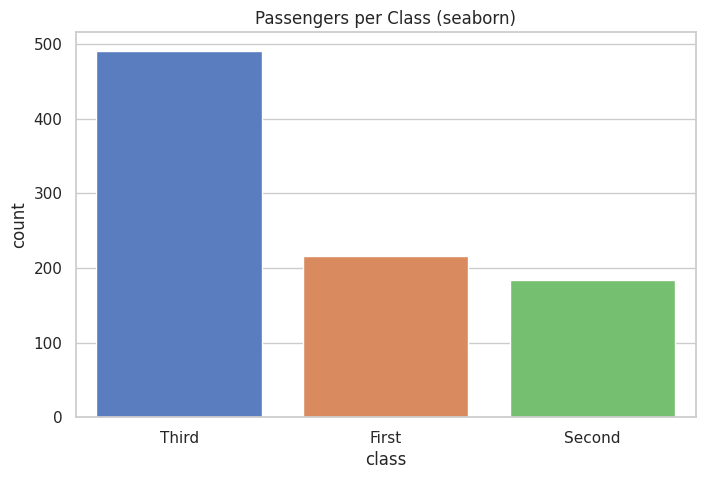

In [ ]:
sns.countplot(data=df, x="class", hue="class", legend=False)
plt.title("Passengers per Class (seaborn)")
plt.show()

### Histogram + density (KDE) in one call

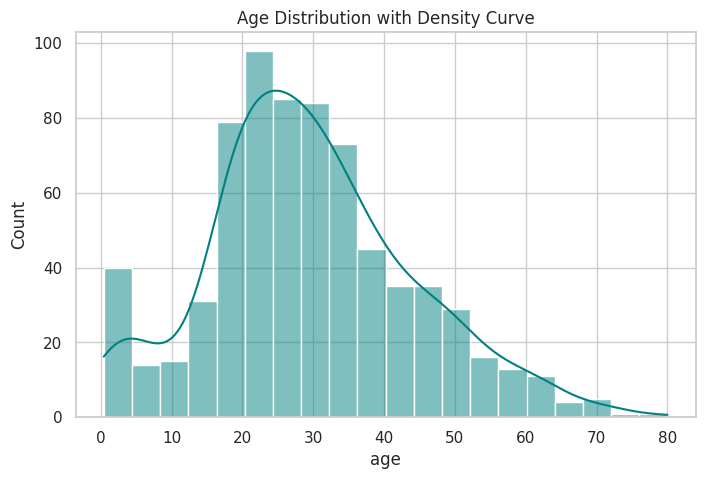

In [ ]:
sns.histplot(data=df, x="age", bins=20, kde=True, color="teal")
plt.title("Age Distribution with Density Curve")
plt.show()

### Fare is heavily skewed — a quick look

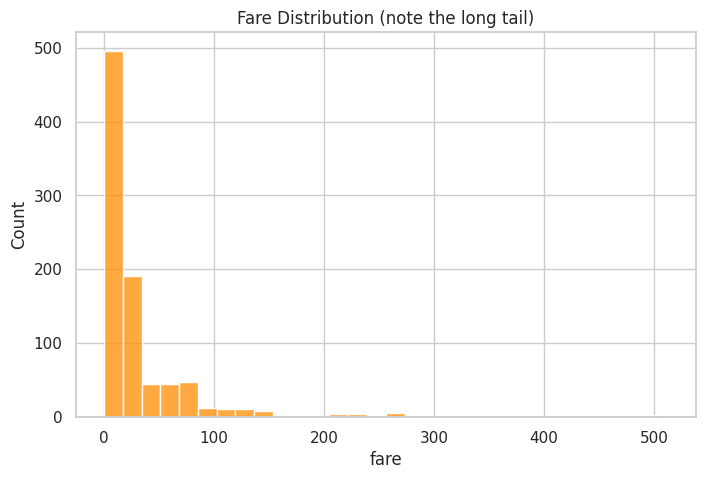

In [ ]:
sns.histplot(data=df, x="fare", bins=30, color="darkorange")
plt.title("Fare Distribution (note the long tail)")
plt.show()

## 5. seaborn: who survived?

The heart of Titanic EDA — survival broken down by other variables.

### Survival rate by sex
`barplot` shows the mean of `survived` (i.e. the survival *rate*) per group, with confidence intervals.

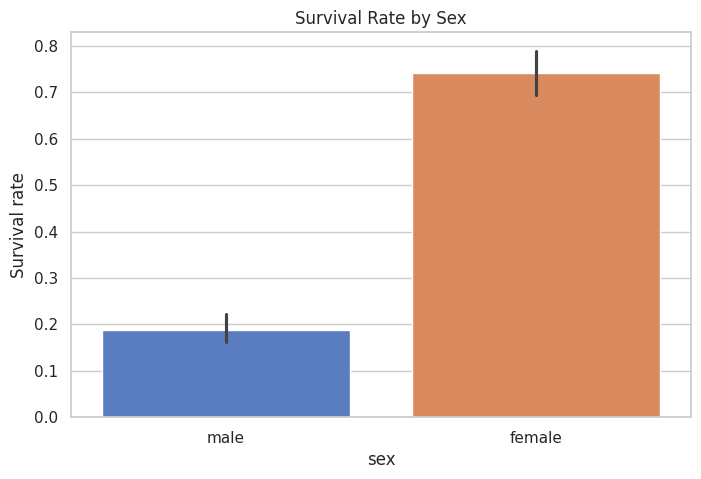

In [ ]:
sns.barplot(data=df, x="sex", y="survived", hue="sex", legend=False)
plt.title("Survival Rate by Sex")
plt.ylabel("Survival rate")
plt.show()

### Survival rate by class and sex together

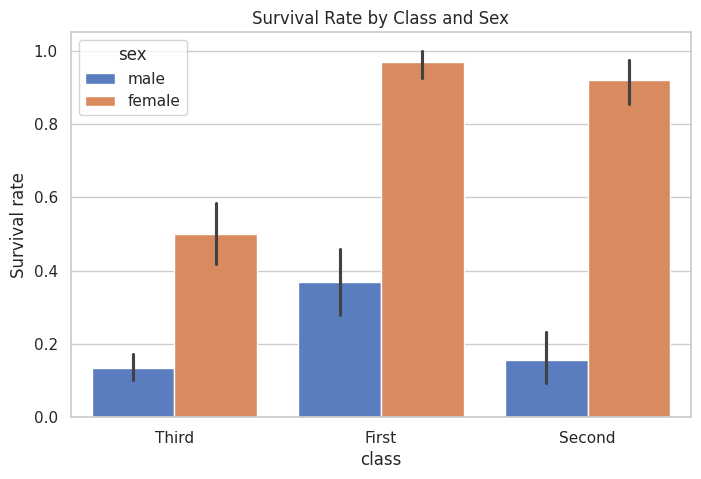

In [ ]:
sns.barplot(data=df, x="class", y="survived", hue="sex")
plt.title("Survival Rate by Class and Sex")
plt.ylabel("Survival rate")
plt.show()

### Counts of survived vs died, split by class

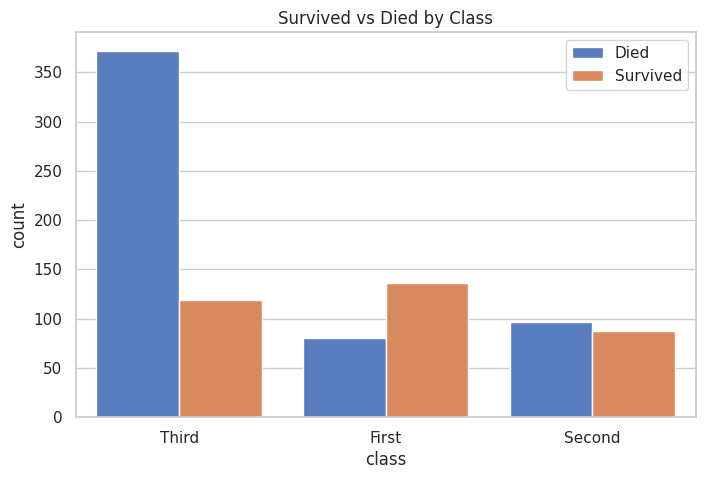

In [ ]:
sns.countplot(data=df, x="class", hue="survived_label")
plt.title("Survived vs Died by Class")
plt.legend(title="")
plt.show()

### Age distribution by survival — boxplot and violin
Boxplots show medians and spread; violins add the full distribution shape.

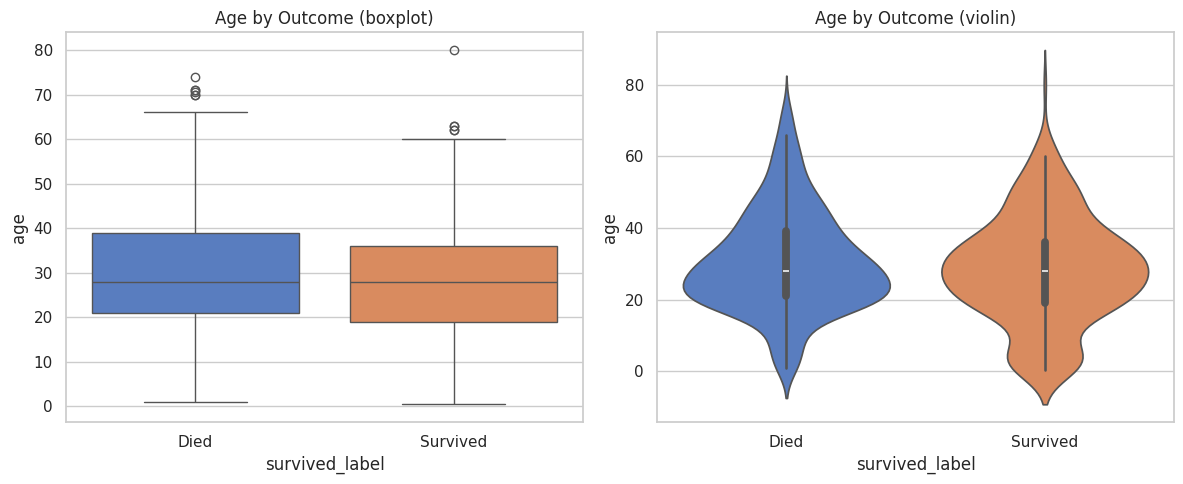

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x="survived_label", y="age", hue="survived_label",
            legend=False, ax=axes[0])
axes[0].set_title("Age by Outcome (boxplot)")
sns.violinplot(data=df, x="survived_label", y="age", hue="survived_label",
               legend=False, ax=axes[1])
axes[1].set_title("Age by Outcome (violin)")
plt.tight_layout()
plt.show()

## 6. Numeric relationships & correlation heatmap

### Scatter of age vs fare, coloured by survival

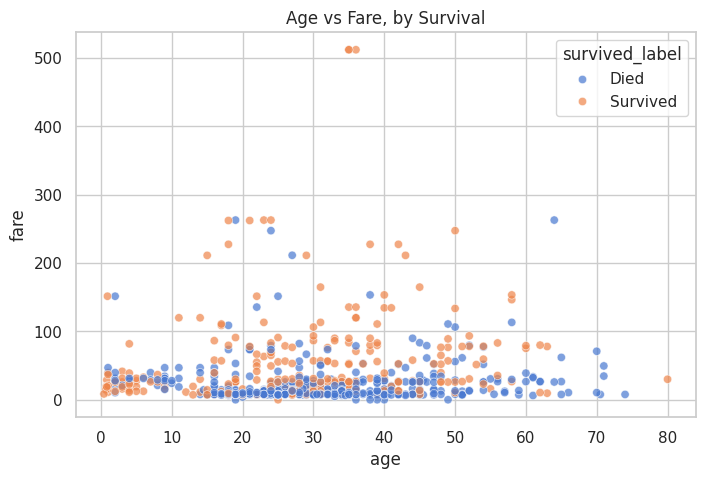

In [ ]:
sns.scatterplot(data=df, x="age", y="fare", hue="survived_label", alpha=0.7)
plt.title("Age vs Fare, by Survival")
plt.show()

### Correlation heatmap of the numeric columns
A staple matplotlib/seaborn combo for spotting relationships at a glance.

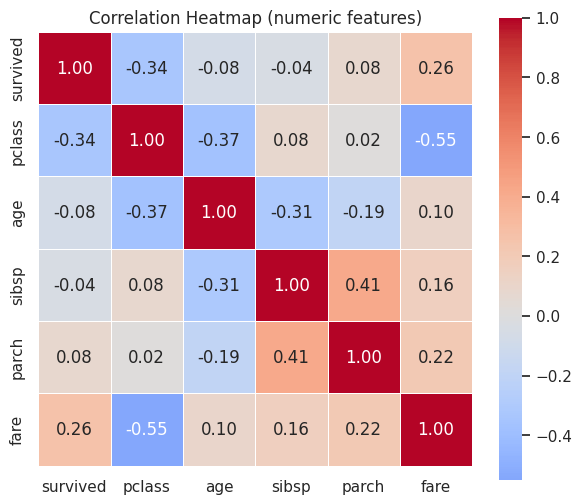

In [ ]:
numeric_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Correlation Heatmap (numeric features)")
plt.show()

## 7. Multivariate / faceted views

`catplot` and `FacetGrid` split one plot into a grid of small multiples — one panel per category.

### Survival rate by class, split into panels by sex

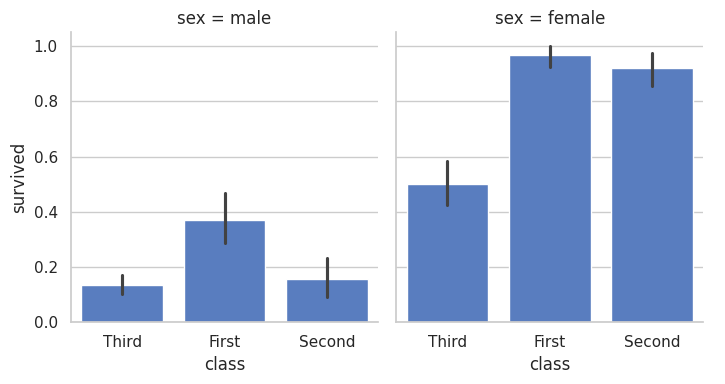

In [ ]:
sns.catplot(data=df, x="class", y="survived", col="sex",
            kind="bar", height=4, aspect=0.9)
plt.show()

### Age distribution per class, faceted

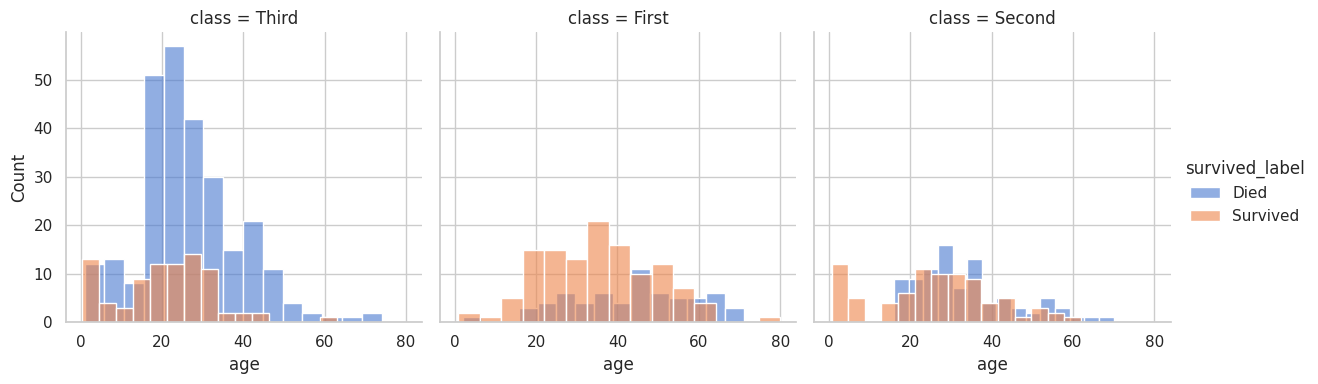

In [ ]:
g = sns.FacetGrid(df, col="class", hue="survived_label", height=4)
g.map(sns.histplot, "age", bins=15, alpha=0.6)
g.add_legend()
plt.show()

## 8. A combined dashboard figure

Pulling several views into one figure with `plt.subplots`, the way you'd assemble a quick summary panel.

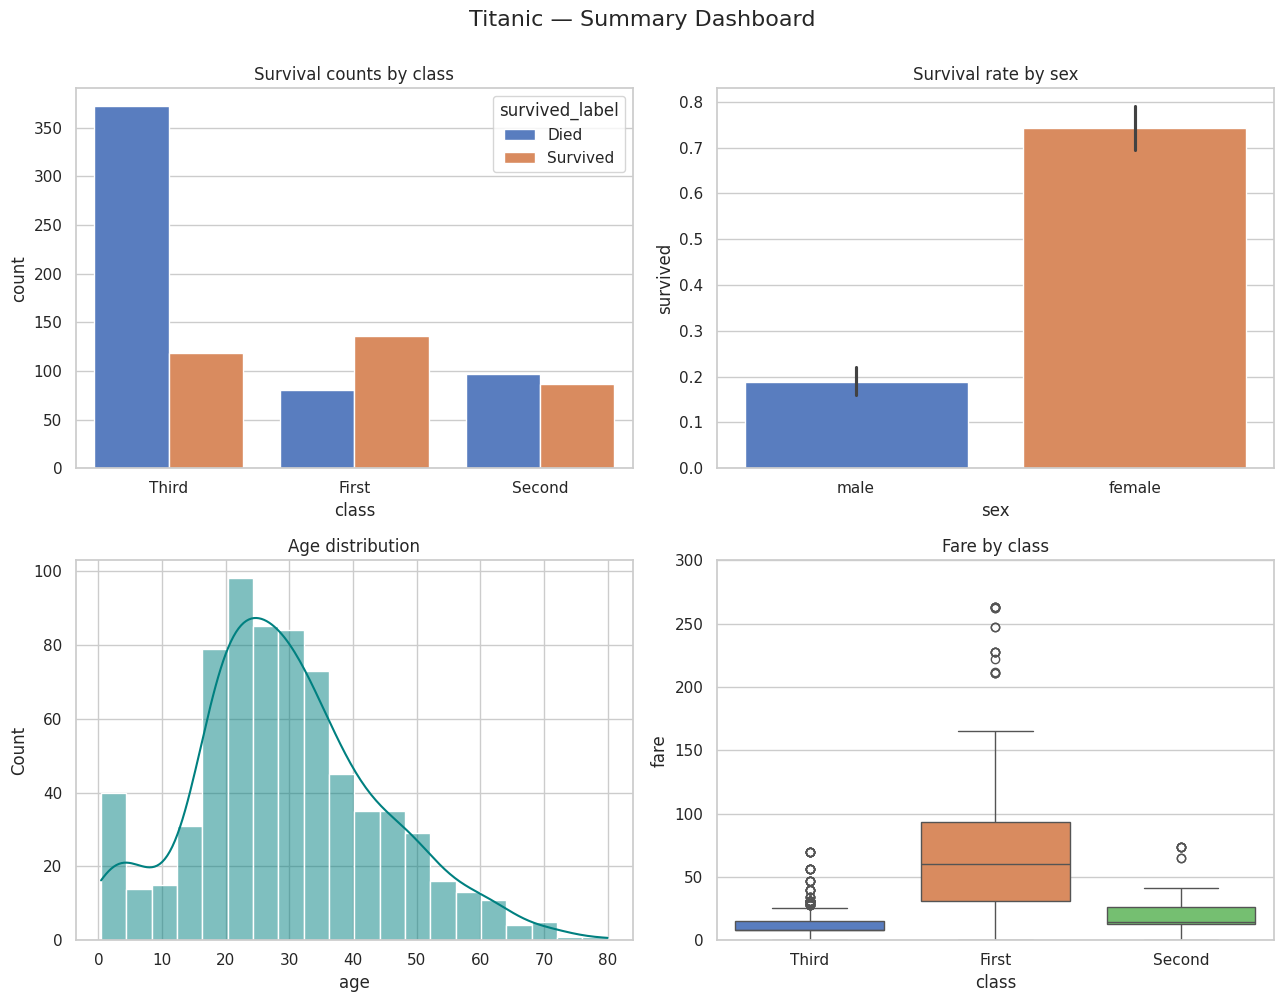

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.countplot(data=df, x="class", hue="survived_label", ax=axes[0, 0])
axes[0, 0].set_title("Survival counts by class")

sns.barplot(data=df, x="sex", y="survived", hue="sex", legend=False, ax=axes[0, 1])
axes[0, 1].set_title("Survival rate by sex")

sns.histplot(data=df, x="age", bins=20, kde=True, ax=axes[1, 0], color="teal")
axes[1, 0].set_title("Age distribution")

sns.boxplot(data=df, x="class", y="fare", hue="class", legend=False, ax=axes[1, 1])
axes[1, 1].set_ylim(0, 300)
axes[1, 1].set_title("Fare by class")

fig.suptitle("Titanic — Summary Dashboard", fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

### Saving a figure to disk
Any figure can be written out with `savefig` — useful for reports and slides.

In [ ]:
fig.savefig("titanic_dashboard.png", dpi=150, bbox_inches="tight")
print("Saved titanic_dashboard.png")

Saved titanic_dashboard.png


## Recap & takeaways

**From the charts**
- Sex was the strongest survival factor — women survived at far higher rates than men.
- Class mattered: 1st-class passengers fared much better than 3rd.
- Fare correlates with survival (it's a proxy for class); age has only a weak effect.

**Plotting patterns to remember**
- matplotlib: `fig, ax = plt.subplots()`, draw on `ax`, label, `plt.show()`.
- seaborn one-liners: `countplot`, `histplot`, `barplot`, `boxplot`, `violinplot`, `scatterplot`, `heatmap`.
- Faceting: `catplot(..., col=...)` or `FacetGrid` for small multiples.
- Combine: pass `ax=` to place seaborn plots into a matplotlib subplot grid.
- Style globally with `sns.set_theme(...)`; export with `fig.savefig(...)`.